# Bank Customer Retention Analytics using AI

**IBM SkillsBuild Data Analytics with AI Internship 2026**  
**Prepared by: Jhil Patel**

## Project Overview

This project uses data analytics to understand bank customer exit patterns and translate analytical findings into business-oriented insights and actions.

The workflow follows:

**Raw Data → Data Cleaning → KPI Analysis → Exploratory Data Analysis → AI-Assisted Interpretation → Business Insights → Business Actions**

## Problem Statement

How can data analytics and AI-assisted interpretation help a bank understand customer exit patterns and identify opportunities to improve customer retention?

## Project Scope

This project focuses on **Data Analytics with AI-assisted insight generation**.

The project does not use machine-learning prediction as its core methodology. The focus is on:

- Data cleaning
- KPI analysis
- Exploratory data analysis
- Customer behaviour analysis
- Pattern identification
- AI-assisted interpretation
- Business recommendations

The analysis identifies observed patterns and associations. It does not claim that any factor directly causes customer exit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "bank_churn_dataset.csv"

if not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        "bank_churn_dataset.csv not found. Upload the CSV to Colab "
        "or place it in the same folder as the notebook."
    )

data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", data.shape)

display(data.head())

Dataset loaded successfully.
Shape: (46025, 26)


/tmp/ipykernel_990/225146581.py:9: DtypeWarning: Columns (14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_PATH)


,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000.0,Phường An Hội (BT),TP. Hồ Chí Minh,0.0,2.0,4.0,8.0,True,03/04/2025,91038993.0,27/02/2025,False,Priority,90.0,Bronze,mobile,0.0359,Low,4.0
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000.0,Phường Bến Thành (Q1),Đồng Nai,3.0,1.0,3.0,2.0,True,14/05/2025,3255569.0,29/07/2021,False,Mass,63.0,Gold,mobile,0.2664,Low,2.0
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000.0,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4.0,0.0,2.0,8.0,False,10/09/2021,0.0,03/03/2021,False,Priority,36.0,Silver,offline,0.1343,Low,4.0
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000.0,Phường 7 (Q7),TP. Hồ Chí Minh,3.0,0.0,4.0,3.0,False,04/03/2025,0.0,12/02/2022,False,Priority,23.0,Bronze,offline,0.2185,Low,4.0
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000.0,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2.0,1.0,4.0,3.0,False,06/08/2022,0.0,24/07/2022,False,Emerging,23.0,Bronze,offline,0.2942,Low,2.0


In [3]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes.to_frame("Data Type"))

Number of rows: 46025
Number of columns: 26

Column names:
['id', 'full_name', 'credit_sco', 'gender', 'age', 'occupation', 'balance', 'monthly_ir', 'address', 'origin_province', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_active_date', 'last_transaction_month', 'created_date', 'exit', 'customer_segment', 'engagement_score', 'loyalty_level', 'digital_behavior', 'risk_score', 'risk_segment', 'cluster_group']

Data types:


,Data Type
id,int64
full_name,object
credit_sco,int64
gender,object
age,int64
occupation,object
balance,int64
monthly_ir,float64
address,object
origin_province,object


In [4]:
missing_values = data.isnull().sum()

missing_table = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .to_frame("Missing Values")
)

if missing_table.empty:
    print("No missing values found.")
else:
    display(missing_table)

print("Total missing values:", int(data.isnull().sum().sum()))
print("Duplicate rows:", int(data.duplicated().sum()))

,Missing Values
monthly_ir,1
address,1
origin_province,1
tenure_ye,1
married,1
nums_card,1
nums_service,1
active_member,1
last_active_date,1
last_transaction_month,1


Total missing values: 19
Duplicate rows: 0


In [5]:
if "exit" not in data.columns:
    raise KeyError("The dataset must contain an 'exit' column.")

exit_counts = data["exit"].value_counts(dropna=False)

print("Customer outcome distribution:")
display(exit_counts.to_frame("Customers"))

if set(data["exit"].dropna().unique()).issubset({0, 1}):
    print("\n0 = Stayed")
    print("1 = Exited")

Customer outcome distribution:


,Customers
exit,
False,37710
True,8314
NaN,1



0 = Stayed
1 = Exited


In [6]:
df = data.copy()

# Remove exact duplicate rows
before_duplicates = len(df)

df = df.drop_duplicates().copy()

duplicates_removed = before_duplicates - len(df)

# Convert date columns
for col in ["last_active_date", "created_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col],
            dayfirst=True,
            errors="coerce"
        )

# Convert exit to numeric
if "exit" in df.columns:
    df["exit"] = pd.to_numeric(
        df["exit"],
        errors="coerce"
    )

    # Remove records where outcome is unavailable
    df = df.dropna(subset=["exit"]).copy()

    df["exit"] = df["exit"].astype(int)

# Convert active_member
if "active_member" in df.columns:

    df["active_member"] = pd.to_numeric(
        df["active_member"],
        errors="coerce"
    )

    # Missing active status is treated as inactive
    df["active_member"] = df["active_member"].fillna(0).astype(int)

print("Duplicates removed:", duplicates_removed)
print("Cleaned dataset shape:", df.shape)
print("Remaining missing values:", int(df.isnull().sum().sum()))

display(df.head())

Duplicates removed: 0
Cleaned dataset shape: (46024, 26)
Remaining missing values: 0


,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000.0,Phường An Hội (BT),TP. Hồ Chí Minh,0.0,2.0,4.0,8.0,1,2025-04-03,91038993.0,2025-02-27,0,Priority,90.0,Bronze,mobile,0.0359,Low,4.0
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000.0,Phường Bến Thành (Q1),Đồng Nai,3.0,1.0,3.0,2.0,1,2025-05-14,3255569.0,2021-07-29,0,Mass,63.0,Gold,mobile,0.2664,Low,2.0
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000.0,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4.0,0.0,2.0,8.0,0,2021-09-10,0.0,2021-03-03,0,Priority,36.0,Silver,offline,0.1343,Low,4.0
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000.0,Phường 7 (Q7),TP. Hồ Chí Minh,3.0,0.0,4.0,3.0,0,2025-03-04,0.0,2022-02-12,0,Priority,23.0,Bronze,offline,0.2185,Low,4.0
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000.0,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2.0,1.0,4.0,3.0,0,2022-08-06,0.0,2022-07-24,0,Emerging,23.0,Bronze,offline,0.2942,Low,2.0


In [7]:
REFERENCE_DATE = pd.Timestamp("2025-09-30")

if {"last_active_date", "created_date"}.issubset(df.columns):

    df["account_age_days"] = (
        df["last_active_date"] - df["created_date"]
    ).dt.days.clip(lower=0)

    df["days_since_last_activity"] = (
        REFERENCE_DATE - df["last_active_date"]
    ).dt.days.clip(lower=0)

    df["created_year"] = df["created_date"].dt.year

    df["last_active_year"] = df["last_active_date"].dt.year

print("Feature engineering completed.")

display(
    df[
        [
            c for c in [
                "created_date",
                "last_active_date",
                "account_age_days",
                "days_since_last_activity",
                "created_year",
                "last_active_year"
            ]
            if c in df.columns
        ]
    ].head()
)

Feature engineering completed.


,created_date,last_active_date,account_age_days,days_since_last_activity,created_year,last_active_year
0,2025-02-27,2025-04-03,35,180,2025,2025
1,2021-07-29,2025-05-14,1385,139,2021,2025
2,2021-03-03,2021-09-10,191,1481,2021,2021
3,2022-02-12,2025-03-04,1116,210,2022,2025
4,2022-07-24,2022-08-06,13,1151,2022,2022


In [8]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Original Rows",
        "Cleaned Rows",
        "Original Columns",
        "Duplicate Rows Removed",
        "Remaining Missing Values"
    ],
    "Value": [
        len(data),
        len(df),
        data.shape[1],
        duplicates_removed,
        int(df.isnull().sum().sum())
    ]
})

display(quality_summary)

,Metric,Value
0,Original Rows,46025
1,Cleaned Rows,46024
2,Original Columns,26
3,Duplicate Rows Removed,0
4,Remaining Missing Values,0


In [9]:
total_customers = len(df)

exited_customers = int(
    (df["exit"] == 1).sum()
)

stayed_customers = int(
    (df["exit"] == 0).sum()
)

exit_rate = (
    exited_customers / total_customers * 100
)

kpis = {
    "Total Customers": total_customers,
    "Exited Customers": exited_customers,
    "Stayed Customers": stayed_customers,
    "Observed Exit Rate (%)": round(exit_rate, 2)
}

if "balance" in df.columns:
    kpis["Average Balance"] = round(
        df["balance"].mean(), 2
    )

if "engagement_score" in df.columns:
    kpis["Average Engagement Score"] = round(
        df["engagement_score"].mean(), 2
    )

if "active_member" in df.columns:
    kpis["Active Customer (%)"] = round(
        df["active_member"].mean() * 100,
        2
    )

kpi_table = pd.DataFrame({
    "KPI": list(kpis.keys()),
    "Value": list(kpis.values())
})

display(kpi_table)

,KPI,Value
0,Total Customers,46024.00
1,Exited Customers,8314.00
2,Stayed Customers,37710.00
3,Observed Exit Rate (%),18.06
4,Average Balance,61209093.72
5,Average Engagement Score,31.83
6,Active Customer (%),21.59


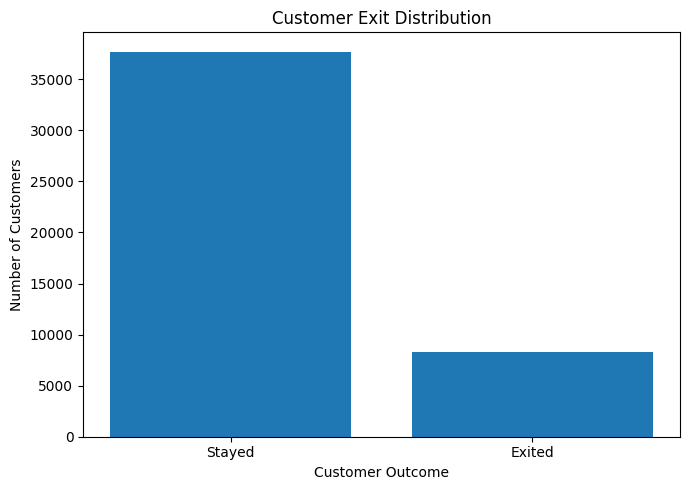

In [10]:
plt.figure(figsize=(7, 5))

labels = ["Stayed", "Exited"]
values = [stayed_customers, exited_customers]

plt.bar(labels, values)

plt.title("Customer Exit Distribution")
plt.xlabel("Customer Outcome")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Observed exit rate by activity:


,Exit Rate (%)
Activity Status,
Active,6.52
Inactive,21.24


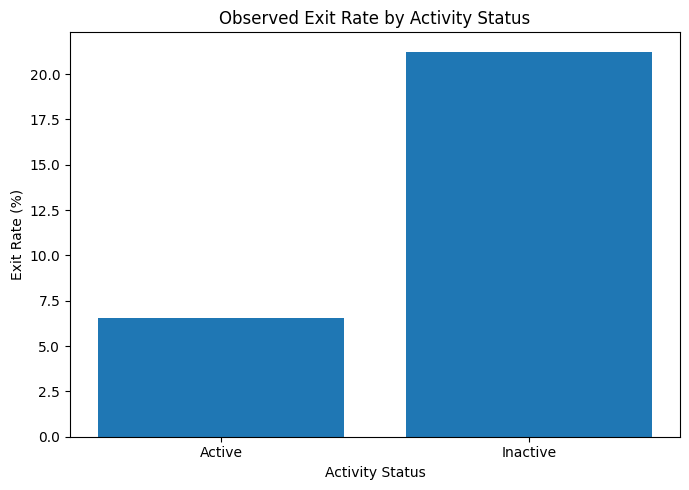

In [11]:
if "active_member" in df.columns:

    activity_df = df.copy()

    activity_df["Activity Status"] = (
        activity_df["active_member"]
        .map({
            0: "Inactive",
            1: "Active"
        })
    )

    activity_exit = (
        activity_df
        .groupby("Activity Status")["exit"]
        .mean()
        .mul(100)
    )

    print("Observed exit rate by activity:")
    display(
        activity_exit
        .round(2)
        .to_frame("Exit Rate (%)")
    )

    plt.figure(figsize=(7, 5))

    plt.bar(
        activity_exit.index,
        activity_exit.values
    )

    plt.title(
        "Observed Exit Rate by Activity Status"
    )

    plt.xlabel("Activity Status")
    plt.ylabel("Exit Rate (%)")

    plt.tight_layout()
    plt.show()

Observed exit rate by customer segment:


,Exit Rate (%)
customer_segment,
Mass,39.39
Emerging,17.91
Affluent,3.19
Priority,0.05


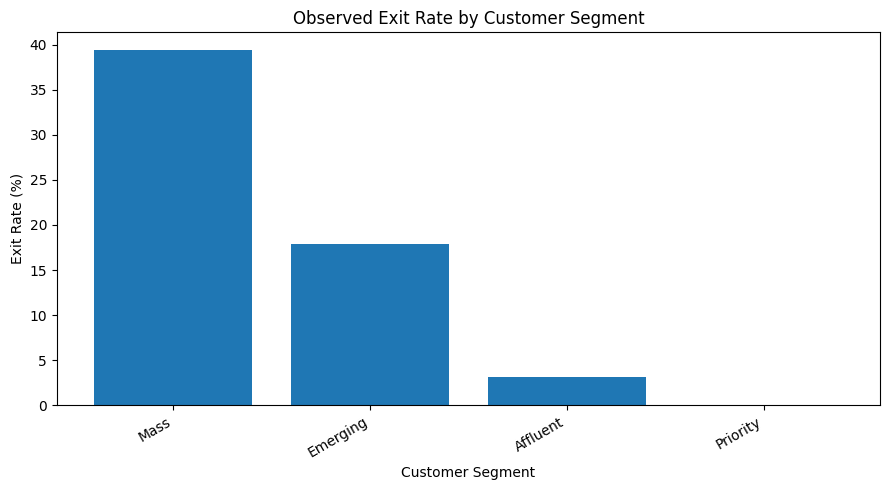

In [12]:
if "customer_segment" in df.columns:

    segment_exit = (
        df.groupby("customer_segment")["exit"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print("Observed exit rate by customer segment:")

    display(
        segment_exit
        .round(2)
        .to_frame("Exit Rate (%)")
    )

    plt.figure(figsize=(9, 5))

    plt.bar(
        segment_exit.index.astype(str),
        segment_exit.values
    )

    plt.title(
        "Observed Exit Rate by Customer Segment"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("Exit Rate (%)")

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

,count,mean,median,min,max
Outcome,,,,,
Exited,8314,20.00,16.0,7.0,97.0
Stayed,37710,34.44,25.0,7.0,100.0


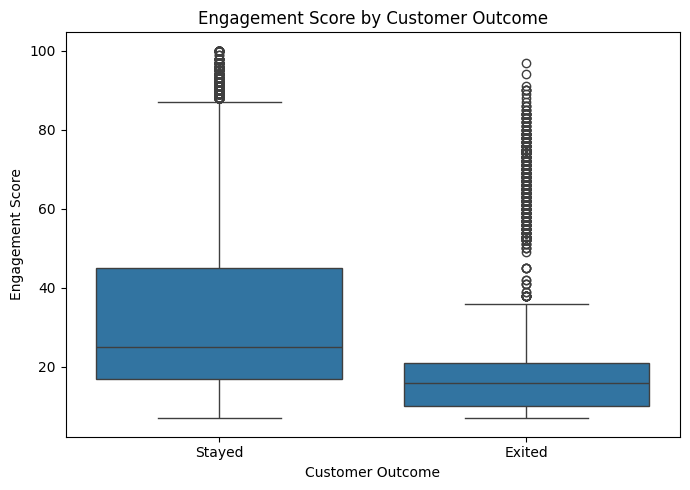

In [13]:
if "engagement_score" in df.columns:

    engagement_df = df.copy()

    engagement_df["Outcome"] = (
        engagement_df["exit"]
        .map({
            0: "Stayed",
            1: "Exited"
        })
    )

    engagement_summary = (
        engagement_df
        .groupby("Outcome")["engagement_score"]
        .agg([
            "count",
            "mean",
            "median",
            "min",
            "max"
        ])
        .round(2)
    )

    display(engagement_summary)

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=engagement_df,
        x="Outcome",
        y="engagement_score"
    )

    plt.title(
        "Engagement Score by Customer Outcome"
    )

    plt.xlabel("Customer Outcome")
    plt.ylabel("Engagement Score")

    plt.tight_layout()
    plt.show()

,Average Balance
exit,
Stayed,70343039.52
Exited,19780046.78


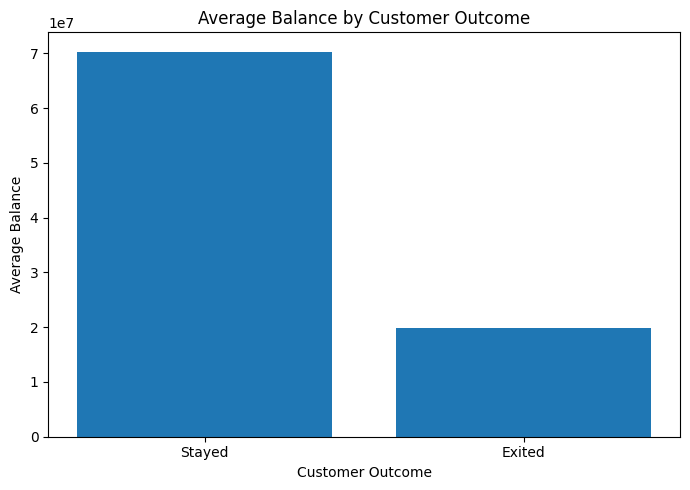

In [14]:
if "balance" in df.columns:

    balance_summary = (
        df.groupby("exit")["balance"]
        .mean()
        .rename({
            0: "Stayed",
            1: "Exited"
        })
    )

    display(
        balance_summary
        .round(2)
        .to_frame("Average Balance")
    )

    plt.figure(figsize=(7, 5))

    plt.bar(
        balance_summary.index,
        balance_summary.values
    )

    plt.title(
        "Average Balance by Customer Outcome"
    )

    plt.xlabel("Customer Outcome")
    plt.ylabel("Average Balance")

    plt.tight_layout()
    plt.show()

In [15]:
if "gender" in df.columns:

    gender_exit = (
        df.groupby("gender")["exit"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    display(
        gender_exit
        .round(2)
        .to_frame("Observed Exit Rate (%)")
    )

,Observed Exit Rate (%)
gender,
female,18.29
male,17.84


In [16]:
if "occupation" in df.columns:

    occupation_exit = (
        df.groupby("occupation")["exit"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    display(
        occupation_exit
        .round(2)
        .to_frame("Observed Exit Rate (%)")
    )

,Observed Exit Rate (%)
occupation,
Nội trợ/Sinh viên,42.50
Lao động phổ thông,35.39
Hưu trí,31.03
Nhân viên văn phòng/Công chức,21.42
Giáo viên/Giảng viên,16.74
Kinh doanh/Bán hàng,15.49
Kế toán/Tài chính,15.02
Kỹ sư/Chuyên viên IT,3.11
Quản lý/Lãnh đạo,0.24


In [17]:
if "origin_province" in df.columns:

    province_exit = (
        df.groupby("origin_province")["exit"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    display(
        province_exit
        .round(2)
        .to_frame("Observed Exit Rate (%)")
    )

,Observed Exit Rate (%)
origin_province,
Tỉnh khác,20.87
Hà Nội,19.45
Đồng Nai,19.09
Tiền Giang,18.70
Bà Rịa - Vũng Tàu,18.67
Long An,18.58
Cần Thơ,18.22
Bình Dương,17.88
TP. Hồ Chí Minh,17.25


In [18]:
if "loyalty_level" in df.columns:

    loyalty_exit = (
        df.groupby("loyalty_level")["exit"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    display(
        loyalty_exit
        .round(2)
        .to_frame("Observed Exit Rate (%)")
    )

,Observed Exit Rate (%)
loyalty_level,
Bronze,20.34
Silver,3.76
Gold,2.15


In [19]:
if "digital_behavior" in df.columns:

    digital_exit = (
        df.groupby("digital_behavior")["exit"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    display(
        digital_exit
        .round(2)
        .to_frame("Observed Exit Rate (%)")
    )

,Observed Exit Rate (%)
digital_behavior,
offline,21.24
mobile,6.52


In [20]:
numeric_columns = [
    col for col in [
        "age",
        "balance",
        "monthly_ir",
        "tenure_ye",
        "nums_card",
        "nums_service",
        "engagement_score",
        "account_age_days",
        "days_since_last_activity"
    ]
    if col in df.columns
]

numeric_comparison = (
    df.groupby("exit")[numeric_columns]
    .mean()
    .T
)

numeric_comparison.columns = [
    "Stayed",
    "Exited"
]

numeric_comparison[
    "Difference (Exited - Stayed)"
] = (
    numeric_comparison["Exited"]
    - numeric_comparison["Stayed"]
)

display(
    numeric_comparison.round(2)
)

,Stayed,Exited,Difference (Exited - Stayed)
age,49.79,47.57,-2.22
balance,70343039.52,19780046.78,-50562992.74
monthly_ir,43021877.49,14522251.62,-28499625.86
tenure_ye,1.80,1.69,-0.10
nums_card,2.71,2.33,-0.38
nums_service,3.83,2.45,-1.38
engagement_score,34.44,20.00,-14.45
account_age_days,420.86,364.03,-56.83
days_since_last_activity,495.00,527.32,32.32


In [21]:
driver_results = []

categorical_columns = [
    "customer_segment",
    "gender",
    "occupation",
    "origin_province",
    "loyalty_level",
    "digital_behavior"
]

for col in categorical_columns:

    if col in df.columns:

        rates = (
            df.groupby(col)["exit"]
            .mean()
            .mul(100)
        )

        if len(rates) > 1:

            driver_results.append({
                "Dimension": col,
                "Highest Exit Rate (%)": round(
                    rates.max(), 2
                ),
                "Lowest Exit Rate (%)": round(
                    rates.min(), 2
                ),
                "Observed Gap (percentage points)": round(
                    rates.max() - rates.min(), 2
                ),
                "Highest-Rate Group": str(
                    rates.idxmax()
                )
            })

driver_summary = pd.DataFrame(
    driver_results
)

display(driver_summary)

,Dimension,Highest Exit Rate (%),Lowest Exit Rate (%),Observed Gap (percentage points),Highest-Rate Group
0,customer_segment,39.39,0.05,39.34,Mass
1,gender,18.29,17.84,0.45,female
2,occupation,42.50,0.11,42.39,Nội trợ/Sinh viên
3,origin_province,20.87,17.25,3.61,Tỉnh khác
4,loyalty_level,20.34,2.15,18.19,Bronze
5,digital_behavior,21.24,6.52,14.72,offline


# AI-Assisted Insight Generation

The analytical calculations are performed using Python.

AI is used as an **analytical assistant** to help convert the calculated evidence into:

**Fact → Insight → Risk/Opportunity → Action**

The AI should receive aggregated tables rather than personal customer information.

### Prompt used for AI-assisted interpretation

> You are a business data analyst reviewing a bank customer-retention dataset.
>
> Using only the supplied KPI and exploratory-analysis tables:
>
> 1. Identify the most important factual patterns.
> 2. Explain the business insight associated with each pattern.
> 3. Identify the related risk or opportunity.
> 4. Suggest a practical business action.
>
> Do not invent numbers.
> Do not claim that a correlation proves causation.
> Do not make predictions about individual customers.
> Keep the analysis concise and suitable for management.
>
> Format each finding as:
>
> **Fact → Insight → Risk/Opportunity → Action**

### Human validation

AI-generated interpretations must be checked against the Python-generated tables before being included in the final report.

In [22]:
print("=" * 60)
print("AI ANALYSIS EVIDENCE PACK")
print("=" * 60)

print("\n1. EXECUTIVE KPIs")
display(kpi_table)

if "active_member" in df.columns:

    print("\n2. ACTIVITY ANALYSIS")
    display(
        activity_exit
        .round(2)
        .to_frame("Exit Rate (%)")
    )

if "customer_segment" in df.columns:

    print("\n3. CUSTOMER SEGMENT ANALYSIS")
    display(
        segment_exit
        .round(2)
        .to_frame("Exit Rate (%)")
    )

if "engagement_score" in df.columns:

    print("\n4. ENGAGEMENT ANALYSIS")
    display(engagement_summary)

if "balance" in df.columns:

    print("\n5. BALANCE ANALYSIS")
    display(
        balance_summary
        .round(2)
        .to_frame("Average Balance")
    )

print("\n6. DRIVER SUMMARY")
display(driver_summary)

AI ANALYSIS EVIDENCE PACK

1. EXECUTIVE KPIs


,KPI,Value
0,Total Customers,46024.00
1,Exited Customers,8314.00
2,Stayed Customers,37710.00
3,Observed Exit Rate (%),18.06
4,Average Balance,61209093.72
5,Average Engagement Score,31.83
6,Active Customer (%),21.59



2. ACTIVITY ANALYSIS


,Exit Rate (%)
Activity Status,
Active,6.52
Inactive,21.24



3. CUSTOMER SEGMENT ANALYSIS


...

,count,mean,median,min,max
Outcome,,,,,
Exited,8314,20.00,16.0,7.0,97.0
Stayed,37710,34.44,25.0,7.0,100.0



5. BALANCE ANALYSIS


,Average Balance
exit,
Stayed,70343039.52
Exited,19780046.78



6. DRIVER SUMMARY


,Dimension,Highest Exit Rate (%),Lowest Exit Rate (%),Observed Gap (percentage points),Highest-Rate Group
0,customer_segment,39.39,0.05,39.34,Mass
1,gender,18.29,17.84,0.45,female
2,occupation,42.50,0.11,42.39,Nội trợ/Sinh viên
3,origin_province,20.87,17.25,3.61,Tỉnh khác
4,loyalty_level,20.34,2.15,18.19,Bronze
5,digital_behavior,21.24,6.52,14.72,offline


# Business Insights

Based on the calculated evidence, the final insights should follow this structure:

### Insight 1 — Customer Exit

**Fact:** The dataset contains both customers who stayed and customers who exited.

**Insight:** The observed exit rate provides the baseline against which customer groups can be compared.

**Opportunity:** Retention activity can be evaluated against this baseline.

**Action:** Track the exit rate regularly as a core management KPI.

---

### Insight 2 — Customer Activity

**Fact:** Exit rates differ between active and inactive customers.

**Insight:** Customer activity is associated with different observed exit levels.

**Risk:** Inactivity can represent a potential early-warning signal.

**Action:** Monitor inactivity and consider targeted customer re-engagement initiatives.

---

### Insight 3 — Customer Segments

**Fact:** Exit rates vary across customer segments.

**Insight:** Customer groups do not demonstrate identical exit patterns.

**Opportunity:** Retention communication can be differentiated by customer group.

**Action:** Investigate the groups with comparatively higher observed exit rates and understand their customer experience.

---

### Insight 4 — Engagement

**Fact:** Engagement scores differ between customers who stayed and customers who exited.

**Insight:** Engagement is an important analytical dimension for understanding customer behaviour.

**Opportunity:** Engagement data can support customer-experience analysis.

**Action:** Monitor engagement trends and evaluate whether re-engagement activities improve customer participation.

---

### Insight 5 — Financial Behaviour

**Fact:** Average balance differs between customers who stayed and those who exited.

**Insight:** Financial characteristics vary across customer outcomes.

**Opportunity:** Customer-value information can be considered alongside engagement and activity.

**Action:** Combine financial and behavioural KPIs when reviewing retention strategies.

> Replace these generic statements with the actual numerical values from the notebook tables before submitting.

# Business Recommendations

1. **Monitor inactivity**
   
   Use customer activity as an early-warning indicator and monitor changes in inactive-customer levels.

2. **Investigate high-exit groups**
   
   Review customer segments and other groups with comparatively high observed exit rates.

3. **Improve customer engagement**
   
   Use engagement and digital-behaviour information to design more relevant re-engagement activities.

4. **Use KPI-driven reporting**
   
   Keep management reporting focused on a small number of meaningful KPIs such as exit rate, activity, engagement and customer value.

5. **Repeat the analysis**
   
   Re-run the analysis periodically to identify changes in customer behaviour and retention patterns.

6. **Use AI as an analyst**
   
   AI-assisted interpretation can help transform analytical tables into concise business insights, provided the generated interpretation is validated against the original data.

# Business Recommendations

1. **Monitor inactivity**
   
   Use customer activity as an early-warning indicator and monitor changes in inactive-customer levels.

2. **Investigate high-exit groups**
   
   Review customer segments and other groups with comparatively high observed exit rates.

3. **Improve customer engagement**
   
   Use engagement and digital-behaviour information to design more relevant re-engagement activities.

4. **Use KPI-driven reporting**
   
   Keep management reporting focused on a small number of meaningful KPIs such as exit rate, activity, engagement and customer value.

5. **Repeat the analysis**
   
   Re-run the analysis periodically to identify changes in customer behaviour and retention patterns.

6. **Use AI as an analyst**
   
   AI-assisted interpretation can help transform analytical tables into concise business insights, provided the generated interpretation is validated against the original data.

# SDG Alignment

## SDG 9 — Industry, Innovation and Infrastructure

This project demonstrates the use of data analytics and AI-assisted interpretation to support technology-enabled decision-making in financial services.

## Secondary Connection — SDG 8

The project also has a conceptual connection to SDG 8 through more systematic and data-driven financial-service operations.

The dataset itself is not an SDG indicator dataset.

# Conclusion

This project demonstrates a complete Data Analytics with AI workflow for understanding bank customer retention.

The project moves from:

**Raw Data → Cleaning → KPIs → Exploratory Analysis → AI-Assisted Interpretation → Business Insights → Actions**

The analysis focuses on measurable customer patterns rather than unnecessary technical complexity.

By combining Python-based analytics with AI-assisted interpretation, the project demonstrates how raw customer data can be transformed into decision-useful business information.

The final approach emphasizes:

**Fact → Insight → Risk/Opportunity → Action**

In [23]:
print("=" * 60)
print("FINAL PROJECT CHECK")
print("=" * 60)

print("Dataset shape:", data.shape)
print("Cleaned dataset shape:", df.shape)

print("\nTotal customers:", total_customers)
print("Stayed customers:", stayed_customers)
print("Exited customers:", exited_customers)
print("Observed exit rate:", round(exit_rate, 2), "%")

print("\nMissing values after cleaning:",
      int(df.isnull().sum().sum()))

print("Duplicate rows after cleaning:",
      int(df.duplicated().sum()))

print("\nProject analysis completed successfully.")

FINAL PROJECT CHECK
Dataset shape: (46025, 26)
Cleaned dataset shape: (46024, 30)

Total customers: 46024
Stayed customers: 37710
Exited customers: 8314
Observed exit rate: 18.06 %

Missing values after cleaning: 0
Duplicate rows after cleaning: 0

Project analysis completed successfully.
